# <center>Sistema de diagnostico de desgaste de machuelos con Aprendizaje Automático - Primera Aproximación</center> #

Zion & Ebenezer Technologies es una empresa metalmecánica ubicada en Atizapán de Zaragoza, México. Su nicho es la produccion y venta de piezas de aluminio y cobre para la industria eléctrica.

## Descripción del problema ##

<div style = "text-align: justify;">
En el área de maquinado por control numérico computarizado (CNC), existe un problema muy recurrente durante el proceso de maquinado conocido como roscado. El roscado es un proceso de maquinado en el cual se desbasta el interior de un barreno pasado o una caja con una herramienta de corte llamada machuelo, el resultado es una rosca interna que sirve de guía y soporte para elementos de sujeción como tornillos. Por su forma y mecanismo de acción, los machuelos son muy propensos a sufrir desgaste de fricción en comparación con otras herramientas de corte, y posteriormente, rupturas súbitas complicadas de predecir que devienen en posibles riesgos para el operador maquinista y para el producto.
</div>


<div style="text-align: center;">
    <img src="machueleado_groover.png", width="150", height="150", style="display: block; margin: 0 auto;">
    
    Proceso de roscado (Groover, 1998)
</div>

<div style = "text-align: justify;">
Durante el periodo de estadia en modelo dual de los alumnos de la Universidad Tecnológica Fidel Velázquez en la empresa Zion & Ebenezer Technologies, se encontro mediante observación empírica que los problemas de ruptura de machuelo a medio proceso de maquinado en donde la herramienta de corte esta en proceso de penetración de la pieza, son constantes y persistentes en la mayoría de líneas de producción que incluyen dicho proceso. El fallo de la herramienta en este punto específico es crítico, ya que fragmentos de la herramienta de corte se quedan insertados en la pieza material lo que provoca su descarte total representando pérdidas productivas y de tiempo.
</div>

## Desarrollo  ##

Para proponer una solución se sugirió un proyecto que consta de tres etapas desarrolladas a profundidad en J.M.S. Granados y D.P. Cumplido, 2026:
1. Adquisición de datos. Se diseña una base de aluminio con imanes de neodimio para acomplar un microcontrolador IoT y un sensor acelerómetro ADXL345 a la carcasa del husillo de un centro de maquinado, se obtienen datos en frecuencia de muestreo de 3200Hz y se envian a un equipo de cómputo para su almacenamiento y estructuración mediante WiFi.
2. Preparación de datos y entrenamiento de modelos. (Esta etapa se expone en este documento)
3. Despliegue de modelo de producción. Se utilizan los datos de entrenamiento del modelo para su ejecución en tiempo real y con ayuda de un segundo microcontrolador mas una pantalla LCD, se implementa una alerta visual del momento de cambio de machuelo. 

## Metodología  ##

<div style = "text-align: justify;">
Para este primer bosquejo de un análisis descriptivo del desgaste de un machuelo en un entorno real de producción en planta. Se siguió una linea de producción de una pieza de cobre de aproximadamente 7 milímetros de ancho, el proceso de maquinado constó de un único machuelo M4 ubicado aproximadamente en medio de la pieza, se tomaron muestras con el dispositivo diseñado en la primera etapa del proyecto en cuatro pasos bien definidos: tres muestras al inicio de la línea de producción, tres muestras después de 30 piezas maquinadas, es decir, pieza número 30, 31 y 32, tres muestras después de 60 piezas maquinadas y finalmente tres muestras despues de 100 piezas maquinadas. La máquina operaba con una velocidad de giro de 364 RPM, y a una velocidad de avance nominal de 254 mm/min. La herramienta de corte era correspondiente a un machuelo M4x0.7mm de dos filos.
</div>

<div></div>


<div style = "text-align: justify;">
La duración aproximada de cada ciclo de machueleado consta de 5 segundos. Se ha identificado que el primer segundo y el último corresponden a las etapas de aproximación y alejamiento del husillo de la posición de seguridad a la superficie de la pieza, mientras que los segundos 2, 3 y 4, corresponden al ciclo de machueleado en si.
</div>

<div></div>

<div style = "text-align: justify;">
El conjunto de datos producido por el microcontrolador ESP32 y el servidor Flask local produce entre 4 y 5 conjuntos de datos CSV con un tamaño de 3200 filas por cada observación, cada conjunto corresponde exactamente a un segundo, debido a la configuración del sensor ADXL345 en frecuencia de muestreo de 3200Hz y el modo interrupción activado.
</div>

<div></div>


<div style = "text-align: justify;">
Debido al teorema de Nyquist, las frecuencia máxima extraible del conjunto de datos es Frecuencia de Muestreo/2 = 1600hz, sin embargo no representa un problema debido al cálculo de las frecuencias base (J.M.S. Granados & D.P. Cumplido, 2026)
</div>

<div></div>

<div style = "text-align: justify;">
Se espera encontrar un comportamiento de desgaste proporcional a la relación empírica de tiempo contra desgaste de herramienta expuesta por la siguiente gráfica:
</div>

<div></div>

<div style="text-align: center;">
    <img src="punto de ruptura de herramienta.png", width="350", height="200", style="display: block; margin: 0 auto;">
    
    Gráfica de desgaste de herramienta (Groover, 1998)
</div>



## Preparación y limpieza de datos ##


Instalación de los paquetes necesarios para trabajar con conjuntos de datos en Python.

In [13]:
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install numpy
!pip install scipy
!pip install xgboost

Importación de los paquetes al entorno de trabajo

In [14]:
import pandas as pd
import sklearn as sck
import numpy as np
import seaborn as sns
import scipy as scp
import matplotlib as mpl
from matplotlib import pyplot as plt

Definicion de una función para extraer los fragmentos de cada observacion en archivos CSV, estructurar y limpiar entradas vacías.

In [15]:
def observation_import_concat(observation_number, list_of_files): #Observation number: número de observación, list_of_files: la lista de los archivos que se extraen de la observación
    temp_list = [] #Lista temporal para almacenar los dataframes de cada archivo CSV por observación.
    total_pd = pd.DataFrame() #Asignar un dataframe vacío para almacenar el resultado final
    for element in list_of_files:
        temp_list.append(pd.read_csv(f'/home/juan/Documentos/Códigos reporte/Pieza_1/muestra{observation_number}/data_set({element}).csv')) #Iterar y extraer cada archivo CSV

    if len(list_of_files) > 2: #Concatenar dataframes cuando la cantidad de archivos es mayor que 2
        for number in range(len(temp_list)): #Iterar sobre lista temporal de acuerdo con la cantidad de objetos en la lista.
            total_pd = pd.concat([total_pd, temp_list[number]], axis = 0) #Concatenar uno por uno
    else:
        total_pd = pd.concat([temp_list[0], temp_list[1]], axis = 0)
        
    total_pd.columns = ['Tiempo(s)', 'G'] #Renombrar columnas
    total_pd.drop(total_pd[total_pd['Tiempo(s)'] == 3200].index, axis = 0, inplace = True) 
    '''
    Limpiar observaciones cuando la columna Tiempo(s) (en este momento corresponde al número de observación), es 3200, es decir el número de observación vacío
    Esto es porque el ESP32 envía los datos en forma de cadena compuesta por varias uniones observación numérica + coma y el flask server los separa con el caracter coma, provocando
    una observación vacía al final.
    '''
    total_pd.reset_index(drop = True, inplace = True) 

    total_pd['Tiempo(s)'] = [x*0.0003125 for x in range(len(total_pd))] 
    '''
    Convertir número de observación a tiempo, la frecuencia de muestreo del sensor es 3200Hz, por lo tanto cada observación corresponde a un
    intervalo de tiempo 1/3200.
    '''
    return total_pd



Ejecutar la función para la observación 3, archivos 0, 1, 2 y 3.

In [16]:
observation_3 = observation_import_concat(3, [0,1,2,3])

Imprimir una gráfica con la señal de vibración.

In [17]:
def plot_observation(observation):

    plt.plot(observation.iloc[:,0], observation.iloc[:,1])
    label_functions = [plt.xlabel, plt.ylabel]
    for label, name in zip(label_functions, observation.columns):
        label(name)
    

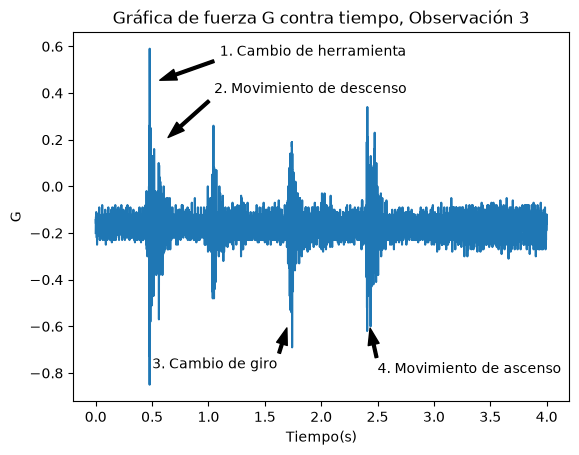

In [18]:
plot_observation(observation_3)
plt.title("Gráfica de fuerza G contra tiempo, Observación 3")
plt.annotate("1. Cambio de herramienta", xy = (0.54, 0.45), xytext = (1.1, 0.56), arrowprops = dict(facecolor = 'black', shrink = 0.05, width = 2, headwidth = 8))
plt.annotate("2. Movimiento de descenso", xy = (0.62, 0.2), xytext = (1.05, 0.4), arrowprops = dict(facecolor = 'black', shrink = 0.05, width = 2, headwidth = 8))
plt.annotate("3. Cambio de giro", xy = (1.7, -0.6), xytext = (0.5, -0.78), arrowprops = dict(facecolor = 'black', shrink = 0.05, width = 2, headwidth = 8))
plt.annotate("4. Movimiento de ascenso", xy = (2.43, -0.6), xytext = (2.5, -0.8), arrowprops = dict(facecolor = 'black', shrink = 0.05, width = 2, headwidth = 8))

plt.show()

<div style = "text-align: justify;">
Al análizar la señal en el tiempo de esta observación se encontraron los siguientes momentos clave:

1. Cambio de herramienta. Es la parte de la señal en donde hay un pico marcado cercano a 0.6G y otro cercano a -0.8G, este comportamiento es de poca duración, se interpreta como un golpe o movimiento en seco por lo que se puede intuir que corresponde a las fases de intercambio de herramienta y movimientos rápidos. La máquina en la que se tomaron las muestras corresponde a un modelo ROMI de la línea D, que en el ciclo de cambio de herramienta presentan movimientos rápidos y secos (G00) y el impacto evidente que se provoca cuando el cambiador de herramientas se ubica en posición de agarre de conos.
2. Movimiento de descenso. El husillo hace un movimiento rápido de descenso (G00) hacia la superficie de la pieza.
3. Cambio de giro. El husillo se detiene de forma abrupta y gira en sentido contrario.
4. Movimiento de ascenso. El husillo se detiene y hace movimiento rápido a posición de seguridad.

Entre la fase 2 y 3 esta el momento crucial de maquinado en la pieza, pues es el proceso de penetración donde el machuelo desbasta la pieza para formar la rosca.

Para dar una prueba intuitiva de la hipótesis, se grafica la información para la observación número 10, que corresponde a 100 piezas maquinadas después de la observación anterior.
</div>

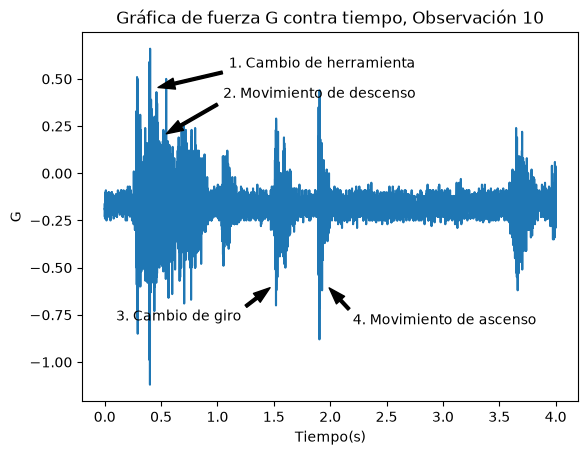

In [19]:
observation_10 = observation_import_concat(10, [0, 1, 2, 3])
plot_observation(observation_10)
plt.title("Gráfica de fuerza G contra tiempo, Observación 10")
plt.annotate("1. Cambio de herramienta", xy = (0.44, 0.45), xytext = (1.1, 0.56), arrowprops = dict(facecolor = 'black', shrink = 0.05, width = 2, headwidth = 8))
plt.annotate("2. Movimiento de descenso", xy = (0.52, 0.2), xytext = (1.05, 0.4), arrowprops = dict(facecolor = 'black', shrink = 0.05, width = 2, headwidth = 8))
plt.annotate("3. Cambio de giro", xy = (1.48, -0.6), xytext = (0.1, -0.78), arrowprops = dict(facecolor = 'black', shrink = 0.05, width = 2, headwidth = 8))
plt.annotate("4. Movimiento de ascenso", xy = (1.98, -0.6), xytext = (2.2, -0.8), arrowprops = dict(facecolor = 'black', shrink = 0.05, width = 2, headwidth = 8))

plt.show()

<div style = "text-align: justify;">
La observación anterior pertenece al conjunto de muestras para el proceso de maquinado despues de haber desbastado 100 piezas, el comportamiento que se observa es similar al que se expuso anteriormente, sin embargo, es importante notar que entre las etapas de movimiento de descenso y cambio de giro, existen registros de una magnitud significativamente mayor, esto podría relacionarse con el desgaste de la herramienta, que al haberse desgastado el filo, los impactos en el material son de fuerza mayor.

Cabe aclarar que la señal no es estrictamente contínua en el tiempo, existe un intervalo entre CSV y CSV de pérdida de datos, debido al tiempo que le toma el microcontrolador enviar la solicitud POST al servidor con los datos, esta pérdida de datos es del órden de fracciones de segundo. Como cada fragmento de la muestra es la recolección de datos correspondiente a un segundo, las pérdidas se presentan en los intervalos discretos 1, 2, 3, ..., n. Sin embargo, y dado que la duración del proceso de desbaste se cronométro con una duración aproximada de 2.8 segundos, es el tiempo suficiente para adquirir información de desbaste, superando la pérdida de información.
</div>

<div style = "text-align: justify;">
Al analizar visualmente las muestras se pueden hacer deducciones tempranas de un aumento de la magnitud de ciertas frecuencias cuando la herramienta de corte está operando con cierto desgaste tras el maquinado de una cantidad de piezas. No obstante aún se carece de información precisa acerca de las frecuencias y sus magnitudes específicas. Para ello, se puede obtener el mapa de frecuencias de la señal con el paquete FFT de SciPy, mediante transformada discreta de Fourier.
</div>

Definir una función para extraer el mapa de frecuencias de la señal con transformada rápida de Fourier:

In [20]:
from scipy.fft import fft, fftfreq

def get_frequency_map(observation):

    sample_frequency = 3200

    y_fft = pd.Series(fft(observation['G']))
    x_fft = pd.Series(fftfreq(len(observation.iloc[:, 0]), 1/sample_frequency)[0:len(observation)//2])

    frequency_map = pd.concat([x_fft, y_fft], axis = 1)
    frequency_map.columns = ['Frecuencia (Hz)', 'Magnitud']
    frequency_map = frequency_map.drop(0)
    frequency_map = frequency_map.drop(frequency_map[(frequency_map['Frecuencia (Hz)'] > 329) & (frequency_map['Frecuencia (Hz)'] < 343 )].index)
    frequency_index = frequency_map.index.tolist()

    index_to_drop = []
    for index in frequency_index:
        if index > 6399:
            index_to_drop.append(index)
    frequency_map = frequency_map.drop(index_to_drop)

    return frequency_map

Definir una función para obtener el top 10 frecuencias presentes en el mapa:

In [21]:
def get_top10_freq(frequency_map):
    frequency_map['Magnitud'] = np.abs(frequency_map['Magnitud'])
    top10_freq = frequency_map.sort_values('Magnitud', ascending = False)[0:10]
    
    return top10_freq

Definir una función para obtener la suma de las magnitudes de las bandas de frecuencia cada 200hz:

In [22]:
def get_wear_band(frequency_map):
    band_list = []
    band_sup_limit = 200
    while band_sup_limit < 1601:
        band_inf_limit = band_sup_limit - 200
        band = frequency_map[(frequency_map['Frecuencia (Hz)'] > band_inf_limit) & (frequency_map['Frecuencia (Hz)'] < band_sup_limit)]
        band['Magnitud'] = np.abs(band['Magnitud'])
        df = pd.DataFrame({f'Total_{band_inf_limit}_to_{band_sup_limit}': [band['Magnitud'].sum()]})
        band_list.append(df)

        band_sup_limit += 200

    all_band_sum = pd.concat(band_list, axis= 1)
    return all_band_sum

<div style = "text-align: justify;">

Aclaración de ingeniería de características: En iteraciónes anteriores del análisis, los datos se estructuraron colocando las top 10 frecuencias y top 10 magnitudes como columnas. Posteriormente, se intentó encontrar una correlación entre la variable objetivo (N. Pieza) y cada una de las variables independientes. De esta manera los resultados fueron mixtos y poco congruentes, se determinó que los datos poseen una organización variable y que las frecuencias y las magnitudes no siempre interactúan de forma directa y concisa en el modelo, pues las relaciones se rompen en el momento que la posición de las frecuencias de forma jerárquica cambia conforme se avanza en el número de pieza, esto es, en la primera columna que corresponde a la frecuencia top 1 de la observación es conciso que se mantiene la frecuencia base 36.5Hz aproximadamente, y en el momento que se pasa al grupo de las 100 piezas, frecuencias mas altas empiezan a ascender y en la pieza numero 12 se desplaza la frecuencia base por un tercer armónico aproximadamente, en este punto, la columna de magnitud que correspondía hasta ese entonces para la frecuencia 36.5Hz, tiene un salto abrupto a la magnitud para la frecuencia 120Hz, por lo tanto, entre columnas no se mantiene una relación concisa. Por ello, se decidió separar el mapa de frecuencias por bandas de 200Hz y hacer una suma total para cada banda, de esta forma se relaciona magnitud y frecuencia de forma efectiva y precisa.

<div>

Obtener mapa de frecuencias de la primera observación:

In [23]:
frequency_map_3 = get_frequency_map(observation_3)
frequency_map_3

,Frecuencia (Hz),Magnitud
1,0.25,12.089757-10.000583j
2,0.50,2.372313- 8.984836j
3,0.75,-9.059105- 2.067067j
4,1.00,-3.636982- 2.762261j
5,1.25,-0.976407+ 1.514130j
...,...,...
6395,1598.75,1.026661+ 0.315629j
6396,1599.00,3.742634- 1.088274j
6397,1599.25,1.970178- 0.719143j
6398,1599.50,-2.128125- 4.190870j


Graficar mapa de frecuencias:

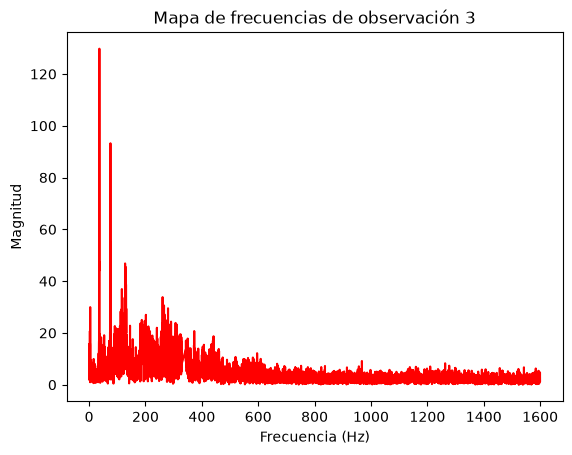

In [24]:
plt.plot(frequency_map_3['Frecuencia (Hz)'], np.abs(frequency_map_3['Magnitud']), color = 'red')
plt.title('Mapa de frecuencias de observación 3')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.show()

Obtener la sumatoria de cada banda de frecuencias:

In [25]:
bands_3 = get_wear_band(frequency_map_3)
bands_3

,Total_0_to_200,Total_200_to_400,Total_400_to_600,Total_600_to_800,Total_800_to_1000,Total_1000_to_1200,Total_1200_to_1400,Total_1400_to_1600
0,7967.396401,7053.381488,4154.728333,2318.782456,1905.296523,1930.733149,1950.711536,1694.1016


Obtener el top 10 frecuencias en la observación:

In [28]:
obs3_top10_freq = get_top10_freq(get_frequency_map(observation_3))
obs3_top10_freq

,Frecuencia (Hz),Magnitud
146,36.50,129.764912
303,75.75,93.248681
301,75.25,55.167144
143,35.75,47.618406
511,127.75,46.844020
521,130.25,45.446358
145,36.25,45.281387
517,129.25,44.232803
144,36.00,44.021327
518,129.50,41.214718


 <div style = "text-align: justify;">
Al realizar un primer bosquejo de las frecuencias dominantes, se encontro que las que se ubican en los primeros 5 lugares, son 36.5Hz, 75.75Hz, 75.23Hz, 35.75Hz y 127.75Hz. Recordando que el machuelo M4x0.7 de dos filos operaba con una velocidad de giro de 364RPM, mediante la fórmula de frecuencia de corte, se obtiene el siguiente resultado:
</div>

$$ f = \frac{364 RPM \cdot 2}{60} = 12.13Hz $$

<div style = 'text-align: justify;'>
Basándonos en el cálculo anterior, la primera frecuencia dominante es remarcable, pues se trata del tercer armónico de la frecuencia base, ya que 36.5/12.13 = 3.009. Con esto podemos hacer una deducción temprana de que efectivamente el sensor ADXL345 está capturando información del evento de desbaste de la herramienta de corte. La razon por la que la frecuencia 12.13Hz no aparece de forma remarcable en las frecuencias dominantes podría deberse a otros factores como la velocidad de avance y la afinación de la máquina. Sin embargo, el armónico es sumamente conciso con la frecuencia calculada de corte.
</div>

Obtener mapa de frecuencias de observación despues de 102 piezas maquinadas:

In [29]:
observation_12 = observation_import_concat(12, [0, 1, 2, 3])
frequency_map_12 = get_frequency_map(observation_10)


Graficar mapa de frecuencias:

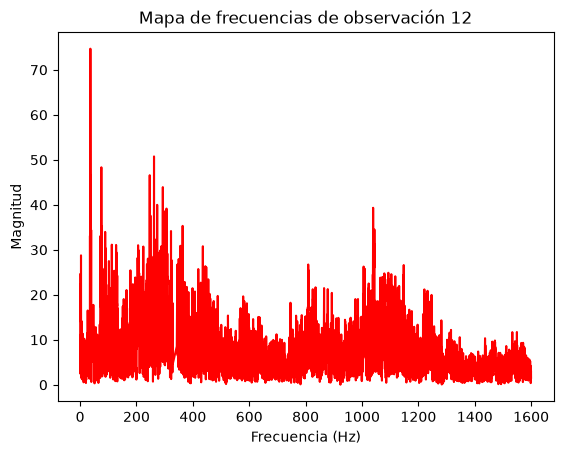

In [30]:
plt.plot(frequency_map_12['Frecuencia (Hz)'], np.abs(frequency_map_12['Magnitud']), color = 'red')
plt.title('Mapa de frecuencias de observación 12')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.show()


<div style = 'text-align: justified;'>
Al analizar el mapa de frecuencias de la observación de la pieza maquinada número 100, se observa claramente el aumento de la magnitud de la mayoría de las frecuencias.

In [31]:
wear_band_12 = get_wear_band(frequency_map_12)
wear_band_12

,Total_0_to_200,Total_200_to_400,Total_400_to_600,Total_600_to_800,Total_800_to_1000,Total_1000_to_1200,Total_1200_to_1400,Total_1400_to_1600
0,8153.889945,10705.390683,6691.636442,4494.459396,6288.31181,8382.026719,4152.066387,3192.762551


In [33]:
obs3_top10_freq = get_top10_freq(get_frequency_map(observation_3))
obs3_top10_freq

,Frecuencia (Hz),Magnitud
146,36.50,129.764912
303,75.75,93.248681
301,75.25,55.167144
143,35.75,47.618406
511,127.75,46.844020
521,130.25,45.446358
145,36.25,45.281387
517,129.25,44.232803
144,36.00,44.021327
518,129.50,41.214718


<div style = 'text-align: justify;'>
Observando la magnitud de las top 10 frecuencias para esta observación, en comparación con la primera, es notable la disminución de la frecuencia base, anteriormente tenía una magnitud de 129.76 unidades frente 74.69. De la misma manera frecuencias altas a partir de 334.5 tienen una magnitud elevada.
</div>


Se define una función "pipeline" para crear una observación completa para el dataset pasando la importanción de los datos por cada uno de los procesos anteriormente mostrados:

In [34]:
def create_observation_pipeline(nobservation, label):
    observation = get_wear_band(get_frequency_map(observation_import_concat(nobservation, [0, 1, 2, 3])))
    observation = pd.concat([observation, pd.DataFrame({'N. Pieza': [label]})], axis = 1)
    return observation


Se define una función para etiquetar cada observación en función del número de archivo y se combinan para crear un conjunto de datos completo:

In [ ]:
def create_dataset(range):
    adder = 0
    obs_list = []
    for i in range:
        if i > 3 and i < 7:
            adder = 26
        elif i > 6 and i< 10:
            adder = 53
        elif i > 9:
            adder = 90
            
        obs_list.append(create_observation_pipeline(i, i + adder))

    return pd.concat(obs_list)

Se crea el conjunto de datos y se reinicia el índice.

In [38]:
dataset = create_dataset(range(1, 14))
dataset = dataset.reset_index(drop = True)

In [37]:
dataset

,Total_0_to_200,Total_200_to_400,Total_400_to_600,Total_600_to_800,Total_800_to_1000,Total_1000_to_1200,Total_1200_to_1400,Total_1400_to_1600,N. Pieza
0,4122.965318,2528.356359,1714.024574,1540.620250,1544.037789,1498.298385,1515.563133,1471.914751,1
1,5537.904550,5583.438181,2324.165847,1814.872908,2179.922860,2233.672259,1620.814637,1540.258932,2
2,7967.396401,7053.381488,4154.728333,2318.782456,1905.296523,1930.733149,1950.711536,1694.101600,3
3,6967.405346,7322.700123,5167.866064,2623.252082,3660.305683,3770.491216,2674.985824,2388.286111,30
4,9588.557031,12698.387342,6899.591324,5375.375157,5597.564997,6512.240590,3676.133938,3290.459151,31
5,7207.983237,8772.632719,4107.577452,2388.611410,2723.380179,2836.070877,1762.713732,1546.876809,32
6,7130.904117,8567.230693,4504.330519,2469.503072,3084.107712,2618.418687,1850.447640,1524.586162,60
7,9598.281788,12299.633992,6872.911147,5118.650056,11160.119976,13171.390301,4014.194416,3294.389252,61
8,7183.636752,9862.786863,7585.133329,5585.291944,6272.339239,7714.917996,4888.085114,5150.971208,62
9,8153.889945,10705.390683,6691.636442,4494.459396,6288.311810,8382.026719,4152.066387,3192.762551,100


In [57]:
dataset.corr()

,Total_0_to_200,Total_200_to_400,Total_400_to_600,Total_600_to_800,Total_800_to_1000,Total_1000_to_1200,Total_1200_to_1400,Total_1400_to_1600,N. Pieza
Total_0_to_200,1.000000,0.954102,0.854356,0.828510,0.846055,0.815041,0.761944,0.699990,0.699811
Total_200_to_400,0.954102,1.000000,0.926858,0.919406,0.880698,0.845242,0.841957,0.800885,0.805992
Total_400_to_600,0.854356,0.926858,1.000000,0.963510,0.863677,0.854311,0.951399,0.919562,0.852434
Total_600_to_800,0.828510,0.919406,0.963510,1.000000,0.892157,0.878675,0.959907,0.948916,0.798360
Total_800_to_1000,0.846055,0.880698,0.863677,0.892157,1.000000,0.985669,0.888587,0.834450,0.806253
Total_1000_to_1200,0.815041,0.845242,0.854311,0.878675,0.985669,1.000000,0.903125,0.826399,0.801783
Total_1200_to_1400,0.761944,0.841957,0.951399,0.959907,0.888587,0.903125,1.000000,0.972673,0.843255
Total_1400_to_1600,0.699990,0.800885,0.919562,0.948916,0.834450,0.826399,0.972673,1.000000,0.776688
N. Pieza,0.699811,0.805992,0.852434,0.798360,0.806253,0.801783,0.843255,0.776688,1.000000


## Análisis Exploratorio de Datos ##

Total_0_to_200 Pearson: 0.6998112097815476
Total_200_to_400 Pearson: 0.805991881817706
Total_400_to_600 Pearson: 0.8524339192878159
Total_600_to_800 Pearson: 0.7983602296012607
Total_800_to_1000 Pearson: 0.806253012327373
Total_1000_to_1200 Pearson: 0.8017830454585178
Total_1200_to_1400 Pearson: 0.8432551395027994
Total_1400_to_1600 Pearson: 0.7766878898652007


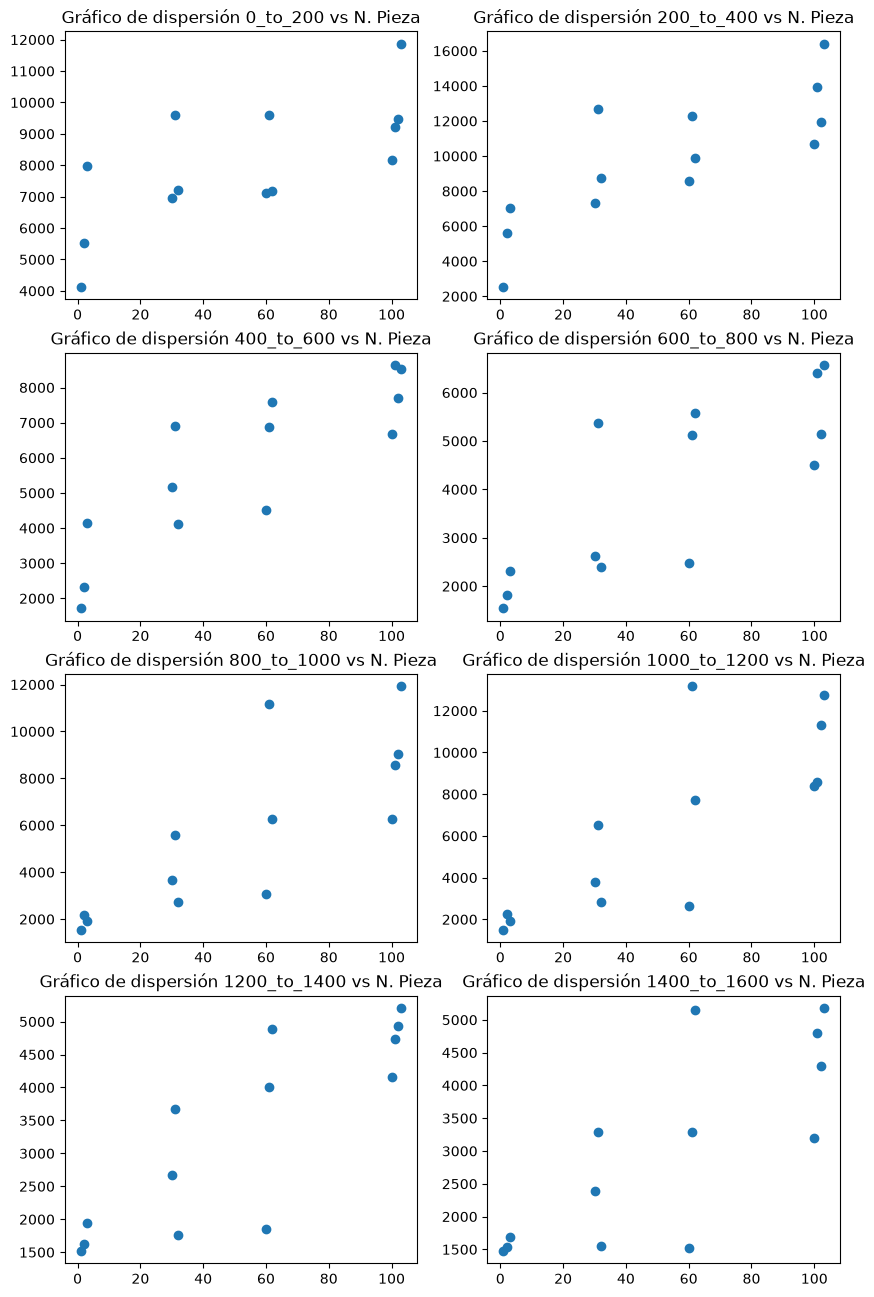

In [80]:
from scipy.stats import pearsonr

fig, ax = plt.subplots(4, 2, figsize = (10, 16))

ax[0,0].scatter(dataset['N. Pieza'], dataset['Total_0_to_200'])
ax[0,0].set_title('Gráfico de dispersión 0_to_200 vs N. Pieza') 

ax[0,1].scatter(dataset['N. Pieza'], dataset['Total_200_to_400'])
ax[0,1].set_title('Gráfico de dispersión 200_to_400 vs N. Pieza') 

ax[1,0].scatter(dataset['N. Pieza'], dataset['Total_400_to_600'])
ax[1,0].set_title('Gráfico de dispersión 400_to_600 vs N. Pieza') 

ax[1,1].scatter(dataset['N. Pieza'], dataset['Total_600_to_800'])
ax[1,1].set_title('Gráfico de dispersión 600_to_800 vs N. Pieza') 

ax[2,0].scatter(dataset['N. Pieza'], dataset['Total_800_to_1000'])
ax[2,0].set_title('Gráfico de dispersión 800_to_1000 vs N. Pieza') 

ax[2,1].scatter(dataset['N. Pieza'], dataset['Total_1000_to_1200'])
ax[2,1].set_title('Gráfico de dispersión 1000_to_1200 vs N. Pieza') 

ax[3,0].scatter(dataset['N. Pieza'], dataset['Total_1200_to_1400'])
ax[3,0].set_title('Gráfico de dispersión 1200_to_1400 vs N. Pieza') 

ax[3,1].scatter(dataset['N. Pieza'], dataset['Total_1400_to_1600'])
ax[3,1].set_title('Gráfico de dispersión 1400_to_1600 vs N. Pieza') 

band_sup_limit = 200
while band_sup_limit < 1601:
    band_inf_limit = band_sup_limit - 200
    band_name = f'Total_{band_inf_limit}_to_{band_sup_limit}'
    band = dataset[band_name]

    print(f'{band_name} Pearson: {pearsonr(dataset['N. Pieza'], dataset[band_name]).statistic}')

    band_sup_limit += 200

<div style = 'text-align:justify;'>

Al analizar las gráficas de dispersión de cada banda de frecuencias contra el número de piezas maquinadas, se observa que, en las primeras dos bandas (representativas de 0-200Hz y 200-400Hz) se discierne un comportamiento similar a la gráfica de Groover, en donde se observa un aumento logaritmico en la frecuencia de corte, seguido por un crecimiento lineal entre 30 a 60 piezas y finalmente un despunte logaritmico a las 100 piezas, es remarcable que en las frecuencias altas a partir de 600 a 800Hz, la varianza en los puntos para las primeras piezas es reducido y sutil, al ser una cantidad pequeña de piezas las analizadas, no se puede afirmar tajantemente este comportamiento. Observando el conjunto de frecuencias en general es evidente un crecimiento lineal de la magnitud de las frecuencias frente al número de pieza, también se observa a simple vista que la varianza es alta, pero nótese como en los "grupos" de piezas, estas se aglomeran al rededor de un punto con una distancia que luce similar entre cada conjunto.

Obteniendo la correlación para cada banda de frecuencias, fue esperable que la que menos correlación tuviera fuera la primer banda, pues en ella reside información de corte (como la frecuencia base y derivados del avance de herramienta). información que a lo largo del historial se mantiene relativamente constante. Descartando dicha banda, las demás presentan una correlación alta que decae en la banda de 1400-1600Hz. La banda de 400-600Hz es la que mas correlación posee, es decir, indica que si la magnitud de esa banda aumenta, entonces el número de pieza maquinada también, aunque es un buen indicio del comportamiento de esta operación de maquinado y el desgaste de su herramienta, no puede ser definitivo, debido a que el método de correlación es lineal promediado, y como la curva de Groover indica, la relación entre tiempo frente a desgaste no es lineal, como se indicó en D.P. Cumplido & J.M. Sánchez (2026) es una función empírica que consta de tres etapas (logaritmica, lineal, exponencial). Dado lo observado en estos datos, el análisis presente podría corresponder a la etapa logaritmica o lineal del desgaste.

Como concepción del diseño, el proyecto se debe implementar como un dispositivo de mantenimiento preventivo que asista y entrene al operador de la máquina para reconocer el daño de la herramienta y poder encontrar el momento óptimo del cambio antes de que ocurra un accidente en la línea de producción y provocar pérdidas en el capital humano y en los activos materiales. Por lo tanto, tras realizar un modelado con una precisión satisfactoria para los efectos dichos, el etiquetado de la variable independiente se realizará en tres categorías correspondientes a la curva de desgaste de Groover: 1. Daño leve (riesgo bajo), 2. Daño medio (riesgo moderado), 3. Daño alto (alto riesgo). El paradigma del mantenimiento preventivo se basa, precisamente, en evitar el error o daño con un margen de seguridad antes de que suceda, y no en llevar al límite los elementos y herramientas de trabajo, por lo que cierto punto de error por parte del modelo de predicción es aceptable, y cuando el detector de daño comience a oscilar entre el aviso de daño medio y daño alto, es entonces donde se recomienda realizar el cambio de herramienta.
</div>

In [81]:
dataset.corr()

,Total_0_to_200,Total_200_to_400,Total_400_to_600,Total_600_to_800,Total_800_to_1000,Total_1000_to_1200,Total_1200_to_1400,Total_1400_to_1600,N. Pieza
Total_0_to_200,1.000000,0.954102,0.854356,0.828510,0.846055,0.815041,0.761944,0.699990,0.699811
Total_200_to_400,0.954102,1.000000,0.926858,0.919406,0.880698,0.845242,0.841957,0.800885,0.805992
Total_400_to_600,0.854356,0.926858,1.000000,0.963510,0.863677,0.854311,0.951399,0.919562,0.852434
Total_600_to_800,0.828510,0.919406,0.963510,1.000000,0.892157,0.878675,0.959907,0.948916,0.798360
Total_800_to_1000,0.846055,0.880698,0.863677,0.892157,1.000000,0.985669,0.888587,0.834450,0.806253
Total_1000_to_1200,0.815041,0.845242,0.854311,0.878675,0.985669,1.000000,0.903125,0.826399,0.801783
Total_1200_to_1400,0.761944,0.841957,0.951399,0.959907,0.888587,0.903125,1.000000,0.972673,0.843255
Total_1400_to_1600,0.699990,0.800885,0.919562,0.948916,0.834450,0.826399,0.972673,1.000000,0.776688
N. Pieza,0.699811,0.805992,0.852434,0.798360,0.806253,0.801783,0.843255,0.776688,1.000000


<div style = 'text-align:justify;'>

Al analizar la tabla de correlación entre cada una de las variables, se observa que entre variables independientes existe mucha colinealidad, segun el principio de no colinealidad presentado en J.M. Sánchez & D.P. Cumplido (2026), toma en cuenta variables independientes con alta colinealidad se considera redundante y costoso en recursos computacionales, por lo tanto, para realizar un primer bosquejo de un modelo de predicción se tomará en cuenta la variable independiente con la mayor correlación y se prescindirá de las demás.

Es importante aclarar que, dado que el conjunto de datos es reducido, se utilizará un método de validación LOO (Leave One Out), que consiste en entrenar el modelo con todo el conjunto de datos menos uno, de forma sucesiva hasta cubrir todos los datos individuales, de esta manera es posible encontrar información mas precisa de predicción cuando hay pocos datos. 

</div>

In [95]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, cross_val_predict

rf = RandomForestRegressor(random_state = 42)

loo = LeaveOneOut()

ss = StandardScaler()

poly = PolynomialFeatures()

pipe = Pipeline([('poly', poly), ('scaler', ss), ('model', rf)])

param_grid = {'model__n_estimators': [1, 2, 3], 'model__max_depth': [None, 1, 2], 'model__criterion':['squared_error', 'poisson'], 'poly__degree': [1, 2, 3]}

grid = GridSearchCV(estimator = pipe, param_grid = param_grid, cv = loo, scoring = 'r2' )

grid.fit(X = pd.DataFrame(dataset['Total_400_to_600']), y = pd.DataFrame(dataset['N. Pieza']))


/home/juan/Documentos/Códigos reporte/Jupyter/.venv/lib/python3.12/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/juan/Documentos/Códigos reporte/Jupyter/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/juan/Documentos/Códigos reporte/Jupyter/.venv/lib/python3.12/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/juan/Documentos/Códigos reporte/Jupyter/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1295: UndefinedMetricWarning: R

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['squared_error', 'poisson'], 'model__max_depth': [None, 1, ...], 'model__n_estimators': [1, 2, ...], 'poly__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",LeaveOneOut()
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 

In [99]:
results = grid.best_estimator_.predict(pd.DataFrame(dataset['Total_400_to_600']))

In [101]:
print(results)

[  3.   3.   3.  30.  61.   3.   3.  61.  62. 100. 101. 102. 103.]


De acuuerdo con los resultados de predicción, el modelo con RandomForestRegressor tuvo un buen rendimiento en las primeras predicciones, recordemos que las primeras tres, corresponden a la pieza 1, 2, 3. En la zona media tuvo aciertos esporadicos con dos errores remarcables (los dos tres), y en la última zona predijo a la perfección las últimas 4 piezas.

In [100]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

print('Puntaje R2:', r2_score(results, dataset['N. Pieza']))
print('MSE:', mean_squared_error(results, dataset['N. Pieza']))

Puntaje R2: 0.7772842639593909
MSE: 384.2307692307692


In [102]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

loo = LeaveOneOut()

ss = StandardScaler()

poly = PolynomialFeatures()

pipe = Pipeline([('poly', poly), ('scaler', ss), ('model', lr)])

param_grid = {'poly__degree': [1, 2, 3]}

grid = GridSearchCV(estimator = pipe, param_grid = param_grid, cv = loo, scoring = 'r2' )

grid.fit(X = pd.DataFrame(dataset['Total_400_to_600']), y = pd.DataFrame(dataset['N. Pieza']))


/home/juan/Documentos/Códigos reporte/Jupyter/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/juan/Documentos/Códigos reporte/Jupyter/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/juan/Documentos/Códigos reporte/Jupyter/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/juan/Documentos/Códigos reporte/Jupyter/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/juan/Documento

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'poly__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",LeaveOneOut()
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fi

In [103]:
results = grid.best_estimator_.predict(pd.DataFrame(dataset['Total_400_to_600']))

In [106]:
results

array([[-7.33148307],
       [ 1.7555212 ],
       [29.01859918],
       [44.10754215],
       [69.89860973],
       [28.31636794],
       [34.2253221 ],
       [69.50125441],
       [80.10857814],
       [66.80147964],
       [95.85899556],
       [81.70986488],
       [94.02934814]])

In [107]:
print('Puntaje R2:', r2_score(results, dataset['N. Pieza']))
print('MSE:', mean_squared_error(results, dataset['N. Pieza']))

Puntaje R2: 0.6238095013411804
MSE: 396.7226477943322


Utilizando regresión lineal, se encontró que los datos predichos, existe una linea de distribución más contínua que la anterior, pues ahora no existen datos con saltos gigantes como se observó en el anterior, sin embargo, se nota en el primer dato predicho que se sale de rango y muestra un valor negativo, que para efectos de la lógica del conjunto de datos, no tiene coherencia, es de notar que el MSE aumentó frente al modelo anterior pero no dramáticamente, indicando que aún el modelo tiene un rendimiento positivo.